In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

FileNotFoundError: [Errno 2] No such file or directory: 'data/voronoi_c_shaped.json'

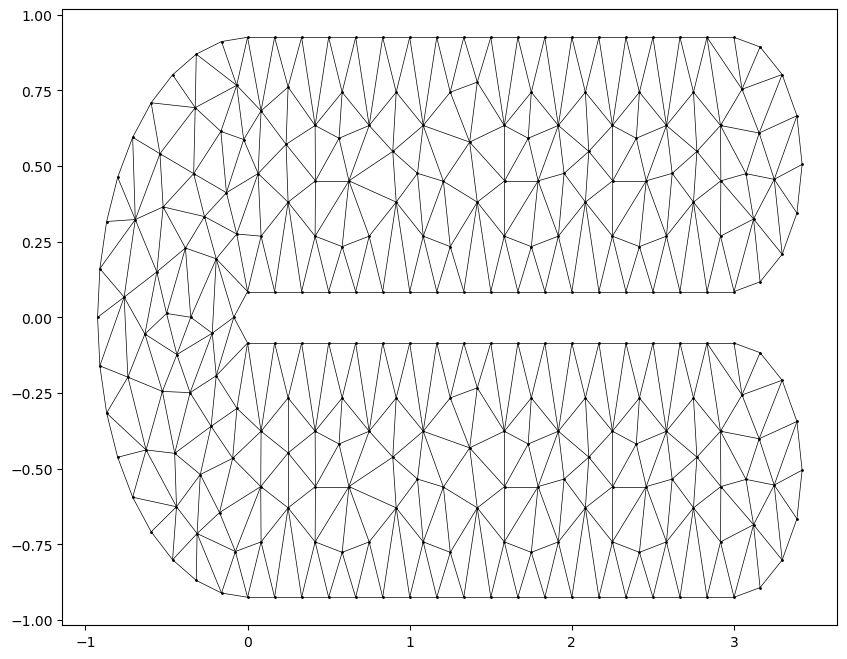

In [4]:
shape = "c_shaped"

def plot_voronoi(
    shape: str,
):
    df_points = pd.read_csv(f"../data/mesh/{shape}/points.csv").rename(columns={'Unnamed: 0': 'id'})

    _ = plt.figure(figsize=(10, 8))
    _ = plt.scatter(df_points['V1'], df_points['V2'], color='black', s=1)
    id2TriaNodes = {}
    for _, row in df_points.iterrows():
        id2TriaNodes[row['id']] = (row['V1'], row['V2'])

    df_edges = pd.read_csv(f"../data/mesh/{shape}/edges.csv").drop(columns='Unnamed: 0')
    triaEdges = []
    for _, row in df_edges.iterrows():
        triaEdges.append([id2TriaNodes[row['V1']], id2TriaNodes[row['V2']]])

    lc = LineCollection(triaEdges, colors='black', linewidths=0.5)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    with open(f"data/voronoi_{shape}.json", 'r') as f:
        data = json.load(f)

    nodes = data['nodes']

    xs = [item['coords'][0] for item in nodes]
    ys = [item['coords'][1] for item in nodes]

    _ = plt.scatter(xs, ys, s=20, color='red')

    id2Node = {d['id']: (d['coords'][0], d['coords'][1]) for d in nodes}
    data
    edges = [[id2Node[d['from']], id2Node[d['to']]] for d in data['edges']]
    edges

    lc = LineCollection(edges, colors='red', linewidths=1)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    plt.show()

plot_voronoi(shape=shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/voronoi_unit_square_16.json'

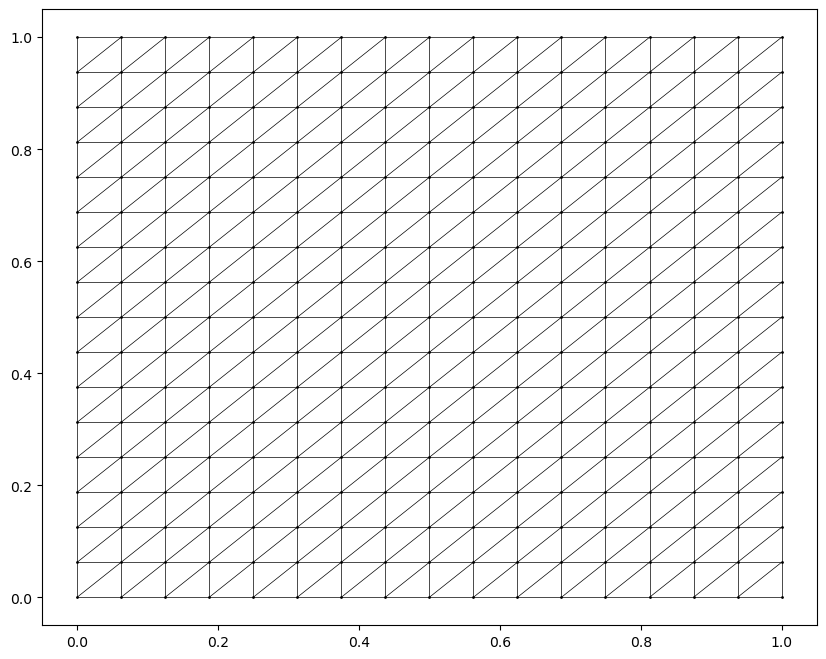

In [5]:
shape = "unit_square_16"
plot_voronoi(
    shape=shape
)

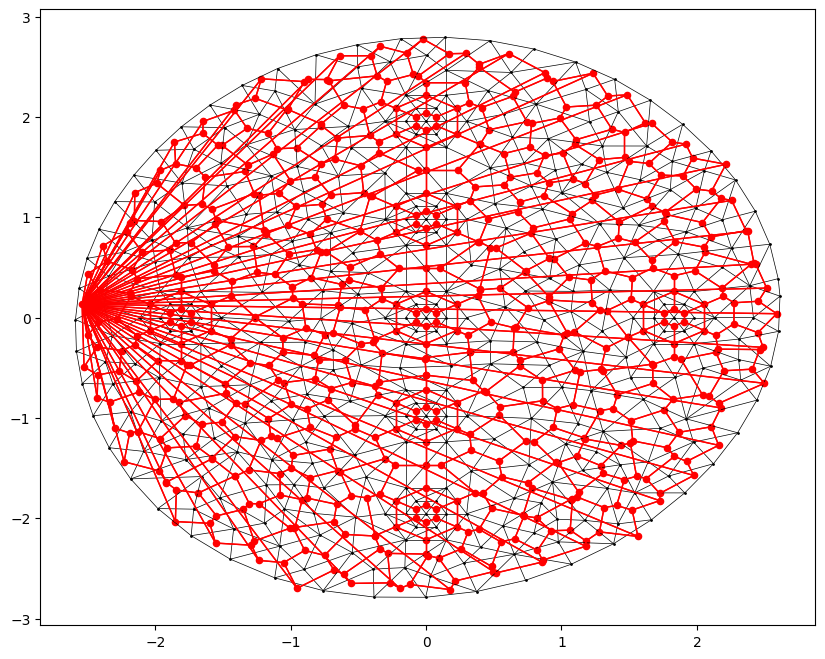

In [6]:
shape = "quasi_circle"
plot_voronoi(
    shape=shape
)